# DENSE AE RESULTS

In [1]:
import os

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt

from sklearn.metrics import roc_curve, auc

import tensorflow as tf
from tensorflow import keras

np.random.seed(42)
tf.random.set_seed(42)

2026-06-23 10:34:49.674543: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-23 10:34:49.766986: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
DENSE_MODELS_DIR = "../models/dense_AE"

MODEL_NAME = "dense_ae_10_mse"

MODEL_PATH = os.path.join(DENSE_MODELS_DIR, f"{MODEL_NAME}.keras")

In [3]:
BACKGROUND_FILE = "../data/datasets/dense/background_dense_dataset.h5"

SIGNAL_FILES = {
    "Ato4l":      "../data/datasets/dense/Ato4l_dense_dataset.h5",
    "hChToTauNu": "../data/datasets/dense/hChToTauNu_dense_dataset.h5",
    "hToTauTau":  "../data/datasets/dense/hToTauTau_dense_dataset.h5",
    "leptoquark": "../data/datasets/dense/leptoquark_dense_dataset.h5",
}

with h5py.File(BACKGROUND_FILE, 'r') as f:
    X_train = f['X_train'][:].astype(np.float32)
    X_val   = f['X_val'][:].astype(np.float32)
    X_test  = f['X_test'][:].astype(np.float32)
print(f'{"X_train":<10}: {X_train.shape}')
print(f'{"X_val":<10}: {X_val.shape}')
print(f'{"X_test":<10}: {X_test.shape}')

signals = {}
for name, path in SIGNAL_FILES.items():
    with h5py.File(path, 'r') as f:
        key = list(f.keys())[0]
        signals[name] = f[key][:].astype(np.float32)
    print(f'{name:<10}: {signals[name].shape}')

X_train   : (8609225, 57)
X_val     : (2152307, 57)
X_test    : (2690383, 57)
Ato4l     : (55969, 57)
hChToTauNu: (760272, 57)
hToTauTau : (691283, 57)
leptoquark: (340544, 57)


In [5]:
dense_ae = keras.models.load_model(MODEL_PATH, compile=False)
dense_ae.summary()

I0000 00:00:1782203856.017330   58092 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13760 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:07.0, compute capability: 7.5


Model: "dense_ae"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 57)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 57)             │           228 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 48)             │         2,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 48)             │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 48)             │         1,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 48)             │           192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_3 (LeakyReLU)       │ (None, 48)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 57)             │         2,793 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 10,509 (41.05 KB)

 Trainable params: 10,075 (39.36 KB)

 Non-trainable params: 434 (1.70 KB)

In [6]:
N_OBJ  = 19
PT_COLS  = [i*3 for i in range(N_OBJ)]
W_CURR = {"pt": 1.0, "eta": 1.0, "phi": 0.5}
PT_STD = X_train[:, PT_COLS].std() + 1e-8

def compute_anomaly_score_physicsloss(model, X, pt_std=PT_STD, weights=W_CURR, batch_size=2048):
    # Anomaly score for each event that replicates the masked_trigger_loss used during training
    Xr = model.predict(X, batch_size=batch_size, verbose=0)

    y_true = tf.reshape(tf.cast(X,  tf.float32), (-1, 19, 3))
    y_pred = tf.reshape(tf.cast(Xr, tf.float32), (-1, 19, 3))

    # --- Maschera: oggetto esiste iff pT != 0 --------------------------------
    # shape (N, 19, 1) → broadcasta su tutte e 3 le feature
    mask = tf.cast(tf.not_equal(y_true[:, :, 0:1], 0.0), tf.float32)

    # --- Numero di oggetti presenti per evento --------------------------------
    # shape (N,)  —  almeno 1 per evitare divisione per zero
    n_present = tf.maximum(tf.reduce_sum(mask, axis=[1, 2]), 1.0)

    pt_true = y_true[:, :, 0:1]
    pt_pred = y_pred[:, :, 0:1]
    pt_loss = tf.square(pt_true - pt_pred) / (pt_std ** 2)

    eta_true = y_true[:, :, 1:2]
    eta_pred = y_pred[:, :, 1:2]
    eta_loss = tf.square((eta_true - eta_pred) / 3.0)

    phi_true = y_true[:, :, 2:3]
    phi_pred = y_pred[:, :, 2:3]
    dphi     = tf.atan2(tf.sin(phi_true - phi_pred), tf.cos(phi_true - phi_pred))
    phi_loss = tf.square(dphi)

    total = (weights["pt"]  * pt_loss +
             weights["eta"] * eta_loss +
             weights["phi"] * phi_loss)
    total = total * mask
    
    n_present = tf.maximum(tf.reduce_sum(mask, axis=[1, 2]), 1.0)
    score = tf.reduce_sum(total, axis=[1, 2]) / n_present
    return score.numpy()

In [7]:
bkg_score = compute_anomaly_score_physicsloss(dense_ae, X_test)
signal_scores = {name: compute_anomaly_score_physicsloss(dense_ae, signals[name]) for name in SIGNAL_FILES.keys()}

print(f"{'Background':<10}: mean={bkg_score.mean():.6f}, std={bkg_score.std():.6f}")
for name in SIGNAL_FILES.keys():
    sc = signal_scores[name]
    print(f"{name:<10}: mean={sc.mean():.6f}, std={sc.std():.6f}")

2026-06-23 10:37:47.070441: I external/local_xla/xla/service/service.cc:163] XLA service 0x7f4ea0003620 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
2026-06-23 10:37:47.070479: I external/local_xla/xla/service/service.cc:171]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
2026-06-23 10:37:47.083054: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:269] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-06-23 10:37:47.144536: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 90300
I0000 00:00:1782203867.615620   58311 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Background: mean=0.120677, std=0.284998
Ato4l     : mean=0.888144, std=1.138171
hChToTauNu: mean=0.609667, std=0.554706
hToTauTau : mean=0.383845, std=0.535173
leptoquark: mean=0.552657, std=0.504949


In [8]:
# ROC / AUC / TPR@FPR=1e-5
FPR_THRESHOLD = 1e-5
target_background = np.zeros(bkg_score.shape[0], dtype=np.float32)

rows = []
for name, sc in signal_scores.items():
    y_true = np.concatenate([np.ones(sc.shape[0], dtype=np.float32), target_background])
    y_pred = np.concatenate([sc, bkg_score])

    fpr, tpr, _ = roc_curve(y_true, y_pred)
    auc_val = auc(fpr, tpr)

    idx = np.searchsorted(fpr, FPR_THRESHOLD, side="right") - 1
    idx = max(idx, 0)
    tpr_at_threshold = tpr[idx]

    rows.append({
        "Signal": name,
        "AUC [%]": 100.0 * auc_val,
        "TPR @ FPR=1e-5 [%]": 100.0 * tpr_at_threshold,
        "TPR @ FPR=1e-5 [# events]": f"{int(round(tpr_at_threshold * sc.shape[0]))} / {sc.shape[0]}",
    })

df_metrics = pd.DataFrame(rows).set_index("Signal")
styled_df = df_metrics.style.format({
    "AUC [%]": "{:.2f}",
    "TPR @ FPR=1e-5 [%]": "{:.4f}",
})

display(styled_df)

,AUC [%],TPR @ FPR=1e-5 [%],TPR @ FPR=1e-5 [# events]
Signal,,,
Ato4l,88.18,0.6629,371 / 55969
hChToTauNu,84.22,0.0289,220 / 760272
hToTauTau,71.07,0.0376,260 / 691283
leptoquark,82.48,0.0073,25 / 340544


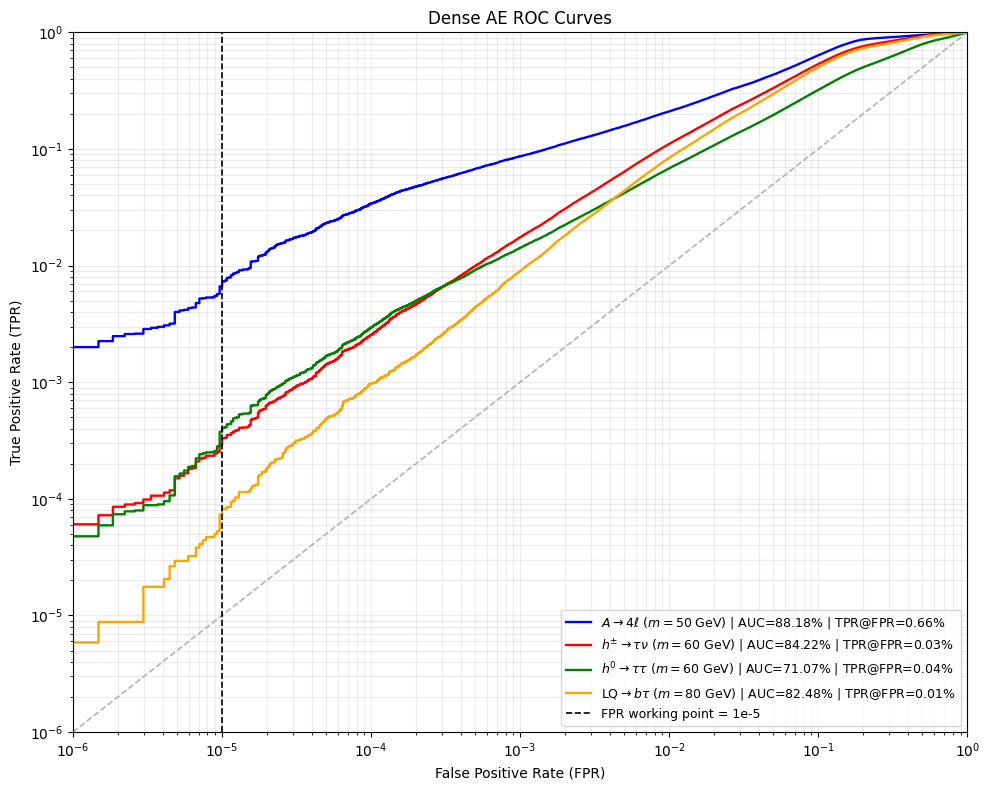

In [9]:
# ROC curves (TPR vs FPR) + working point at FPR=1e-5

sample_colors = {
    "background": "black",
    "Ato4l":      "blue",
    "hChToTauNu": "red",
    "hToTauTau":  "green",
    "leptoquark": "orange",
}

signal_labels = {
    "Ato4l": r"$A \rightarrow 4\ell$ ($m = 50\text{ GeV}$)",
    "hChToTauNu": r"$h^{\pm} \rightarrow \tau \nu$ ($m = 60\text{ GeV}$)",
    "hToTauTau": r"$h^0 \rightarrow \tau \tau$ ($m = 60\text{ GeV}$)",
    "leptoquark": r"$\text{LQ} \rightarrow b \tau$ ($m = 80\text{ GeV}$)",
}

plt.figure(figsize=(10, 8))

for name in SIGNAL_FILES.keys():
    sc = signal_scores[name]
    y_true = np.concatenate([np.ones(sc.shape[0], dtype=np.float32), target_background])
    y_pred = np.concatenate([sc, bkg_score])

    fpr, tpr, _ = roc_curve(y_true, y_pred)
    auc_val = auc(fpr, tpr)

    idx = np.searchsorted(fpr, FPR_THRESHOLD, side="right") - 1
    idx = max(idx, 0)
    tpr_at_threshold = tpr[idx]

    plt.plot(
        fpr,
        tpr,
        linewidth=1.7,
        color=sample_colors[name],
        label=f"{signal_labels[name]} | AUC={auc_val*100:.2f}% | TPR@FPR={tpr_at_threshold*100:.2f}%",
    )

plt.plot([1e-6, 1.0], [1e-6, 1.0], "--", color="0.70", linewidth=1.2)
plt.axvline(FPR_THRESHOLD, color="black", linestyle="--", linewidth=1.2, label="FPR working point = 1e-5")

plt.xscale("log")
plt.yscale("log")
plt.xlim(1e-6, 1.0)
plt.ylim(1e-6, 1.0)
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Dense AE ROC Curves")
plt.grid(True, which="both", alpha=0.25)
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

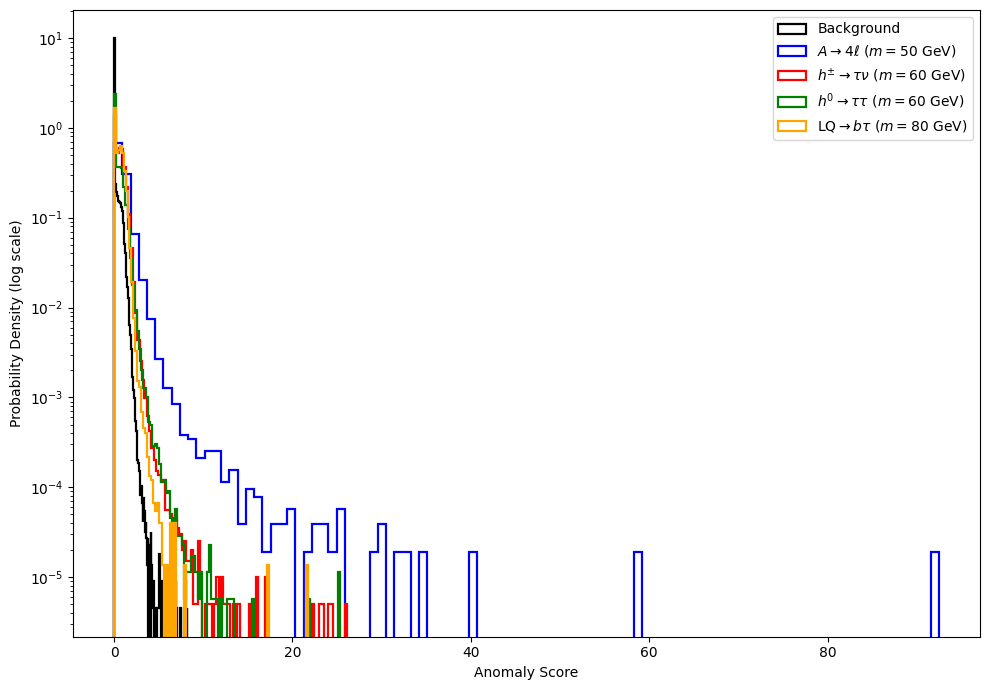

In [10]:
plt.figure(figsize=(10, 7))

plt.hist(bkg_score, bins=100, density=True, histtype="step", 
         linewidth=1.6, label="Background", color=sample_colors["background"])

# Segnali con i loro rispettivi colori fissati
for name in SIGNAL_FILES.keys():
    plt.hist(signal_scores[name], bins=100, density=True, histtype="step", 
             linewidth=1.6, label=signal_labels[name], color=sample_colors[name])

plt.yscale("log")
plt.xlabel("Anomaly Score")
plt.ylabel("Probability Density (log scale)")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [11]:
# Export only required artifacts for model comparison
from pathlib import Path

# Output folder: ../results/dense_AE/<model_name>
model_name = Path(MODEL_PATH).stem
out_dir = Path("../results/dense_AE") / model_name
out_dir.mkdir(parents=True, exist_ok=True)
PNG_DPI = 300

# Common labels/colors
signal_names = list(signal_scores.keys())
signal_labels = {name: name for name in signal_names}
color_map = {
    "background": sample_colors.get("background", "black"),
    **{name: sample_colors.get(name, None) for name in signal_names},
}

# 1) Save score distributions plot (PNG only)
fig_scores = plt.figure(figsize=(10, 7))
plt.hist(
    bkg_score,
    bins=100,
    density=True,
    histtype="step",
    linewidth=1.6,
    label="Background",
    color=color_map["background"],
)
for name in signal_names:
    plt.hist(
        signal_scores[name],
        bins=100,
        density=True,
        histtype="step",
        linewidth=1.6,
        label=signal_labels[name],
        color=color_map[name],
    )
plt.yscale("log")
plt.xlabel("Anomaly Score")
plt.ylabel("Probability Density (log scale)")
plt.legend(loc="upper right")
plt.tight_layout()
fig_scores.savefig(out_dir / "scores.png", dpi=PNG_DPI, bbox_inches="tight")
plt.close(fig_scores)

# 2) Build ROC payload and save ROC plot (PNG only)
roc_payload = {}
metrics_rows = []

fig_roc = plt.figure(figsize=(10, 8))
for name in signal_names:
    sc = signal_scores[name]
    y_true = np.concatenate([np.ones(sc.shape[0], dtype=np.float32), target_background])
    y_pred = np.concatenate([sc, bkg_score])

    fpr, tpr, thresholds = roc_curve(y_true, y_pred)
    auc_val = auc(fpr, tpr)

    idx = np.searchsorted(fpr, FPR_THRESHOLD, side="right") - 1
    idx = max(idx, 0)
    tpr_at_threshold = tpr[idx]

    roc_payload[name] = {
        "fpr": fpr.astype(np.float32),
        "tpr": tpr.astype(np.float32),
        "thresholds": thresholds.astype(np.float32),
        "auc": np.array([auc_val], dtype=np.float64),
        "tpr_at_fpr_1e5": np.array([tpr_at_threshold], dtype=np.float64),
    }

    metrics_rows.append({
        "Signal": name,
        "AUC [%]": 100.0 * auc_val,
        "TPR @ FPR=1e-5 [%]": 100.0 * tpr_at_threshold,
        "TPR @ FPR=1e-5 [# events]": f"{int(round(tpr_at_threshold * sc.shape[0]))} / {sc.shape[0]}",
    })

    plt.plot(
        fpr,
        tpr,
        linewidth=1.7,
        color=color_map[name],
        label=f"{signal_labels[name]} | AUC={auc_val*100:.2f}% | TPR@FPR={tpr_at_threshold*100:.2f}%",
    )

plt.plot([1e-6, 1.0], [1e-6, 1.0], "--", color="0.70", linewidth=1.2)
plt.axvline(FPR_THRESHOLD, color="blue", linestyle="--", linewidth=1.2, label="FPR working point = 1e-5")
plt.xscale("log")
plt.yscale("log")
plt.xlim(1e-6, 1.0)
plt.ylim(1e-6, 1.0)
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR)")
plt.title("Dense AE ROC Curves")
plt.grid(True, which="both", alpha=0.25)
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
fig_roc.savefig(out_dir / "roc.png", dpi=PNG_DPI, bbox_inches="tight")
plt.close(fig_roc)

# 3) Save numeric artifacts
score_save = {"bkg_score": bkg_score.astype(np.float32)}
for name in signal_names:
    score_save[f"score_{name}"] = signal_scores[name].astype(np.float32)
np.savez_compressed(out_dir / "scores.npz", **score_save)

roc_save = {}
for name in signal_names:
    roc_save[f"fpr_{name}"] = roc_payload[name]["fpr"]
    roc_save[f"tpr_{name}"] = roc_payload[name]["tpr"]
    roc_save[f"thresholds_{name}"] = roc_payload[name]["thresholds"]
    roc_save[f"auc_{name}"] = roc_payload[name]["auc"]
    roc_save[f"tpr_at_fpr_1e5_{name}"] = roc_payload[name]["tpr_at_fpr_1e5"]
np.savez_compressed(out_dir / "roc_data.npz", **roc_save)

# 4) Save tabular metrics
df_metrics_export = pd.DataFrame(metrics_rows).set_index("Signal")
df_metrics_export.to_csv(out_dir / "metrics.csv")

print(f"Export completed: {out_dir}")
print("Saved files:")
for name in ["metrics.csv", "roc.png", "scores.png", "roc_data.npz", "scores.npz"]:
    print(" -", name)

Export completed: ../results/dense_AE/dense_ae_10_mse
Saved files:
 - metrics.csv
 - roc.png
 - scores.png
 - roc_data.npz
 - scores.npz
